In [10]:
words= open("names.txt",'r').read().splitlines()
import torch 

In [11]:
N=torch.zeros((27,27),dtype=torch.int32)
chars=[chr(i) for i in range(ord('a'),ord('z')+1)]

In [12]:
d={chars[i]:i+1 for i in range(len(chars))}
d["."]=0

In [13]:
for name in words:
    ch=["."]+list(name)+["."]
    for L,C in zip(ch,ch[1:]):
        N[d[L],d[C]]+=1

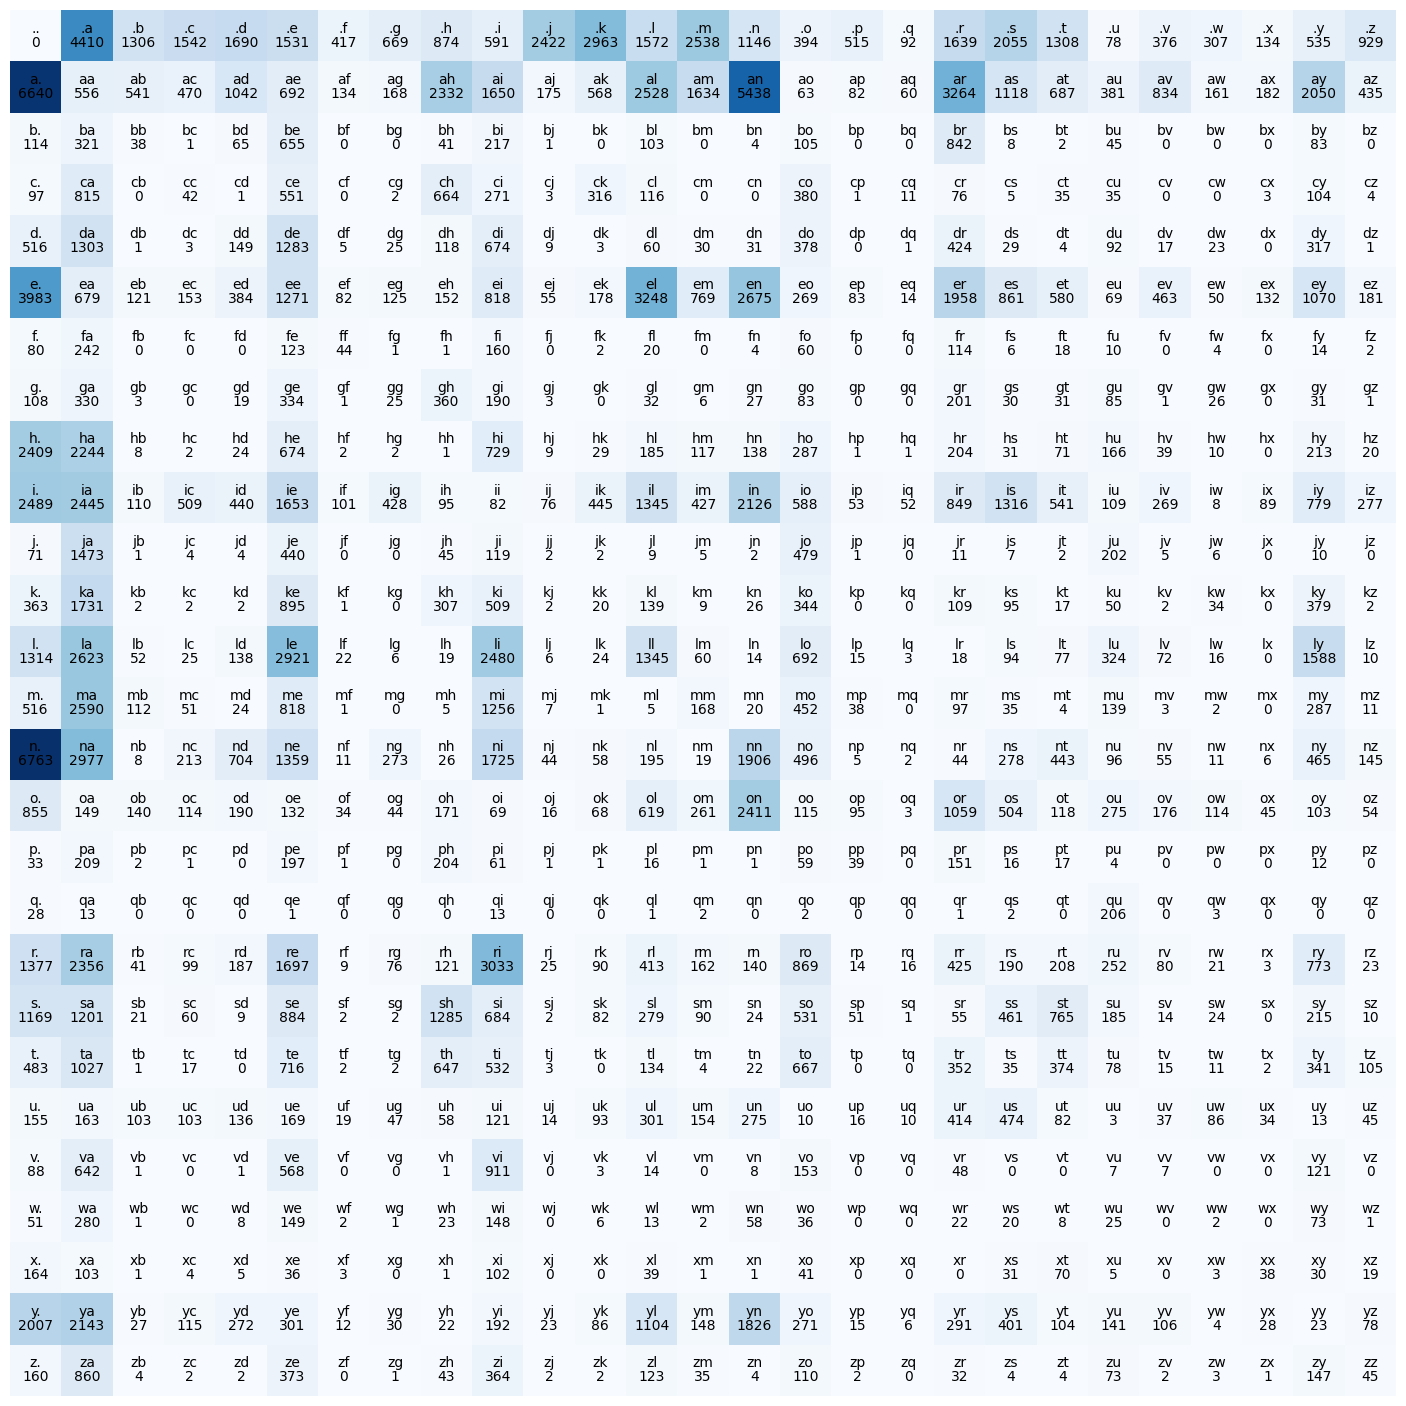

In [14]:
import matplotlib.pyplot as plt 
itos = {i:s for s,i in d.items()}
plt.figure(figsize=(18,18))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off');

In [15]:
P=(N+1).float()
P=P/N.float().sum(1,keepdim=True)
g=torch.Generator().manual_seed(2147483647)
ix=0
for i in range(5):
    word=""
    while True:
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        word+=itos[ix]
        if ix==0:
            break
    print(word)


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [16]:
xs,ys=[],[]
for name in words:
    ch=["."]+list(name)+["."]
    for L,C in zip(ch,ch[1:]):
        xs.append(d[L])
        ys.append(d[C])
xs=torch.tensor(xs)
num=len(xs)
ys=torch.tensor(ys)

In [17]:
import torch.nn.functional as f
xe=f.one_hot(xs,num_classes=27).float()
g=torch.Generator().manual_seed(2147483647)
w=torch.randn((27,27),generator=g,requires_grad=True)

In [19]:
for i in range(100):
    count=(xe@w).exp()# logits[i,j] represents the weight of having the caracter of index j after the caractere of line i in xe
    prob=count/count.sum(1,keepdim=True)
    loss=-prob[torch.arange(num),ys].log().mean()
    w.grad=None
    loss.backward()
    w.data+=-50*w.grad
print(loss.item())

2.4728763103485107


In [20]:
#generate names
print()
g=torch.Generator().manual_seed(2147483647)
for i in range(5):
    word=""
    ix=0
    while True:
        xe=f.one_hot(torch.tensor([ix]),num_classes=27).float()    
        logits=(xe@w)
        count=logits.exp()
        prob=count/count.sum(1,keepdim=True)
        ix=torch.multinomial(prob,num_samples=1,replacement=True,generator=g)
        word+=itos[ix.item()]
        if ix==0:
            break
    print(word)


cexze.
momasurailezityha.
konimittain.
llayn.
ka.
